### Principal Component Analysis (PCA)

In [44]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [45]:
# Load the dataset
df= pd.read_csv("wine.csv")

In [46]:
# display first 5 rows
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [47]:
#display total no of rows & columns
df.shape

(178, 14)

In [48]:
#dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [49]:
# statistical summary
df.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [50]:
# check for duplicate values
df.duplicated().sum()

np.int64(0)

In [51]:
# check for missing values
df.isnull().sum()

Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

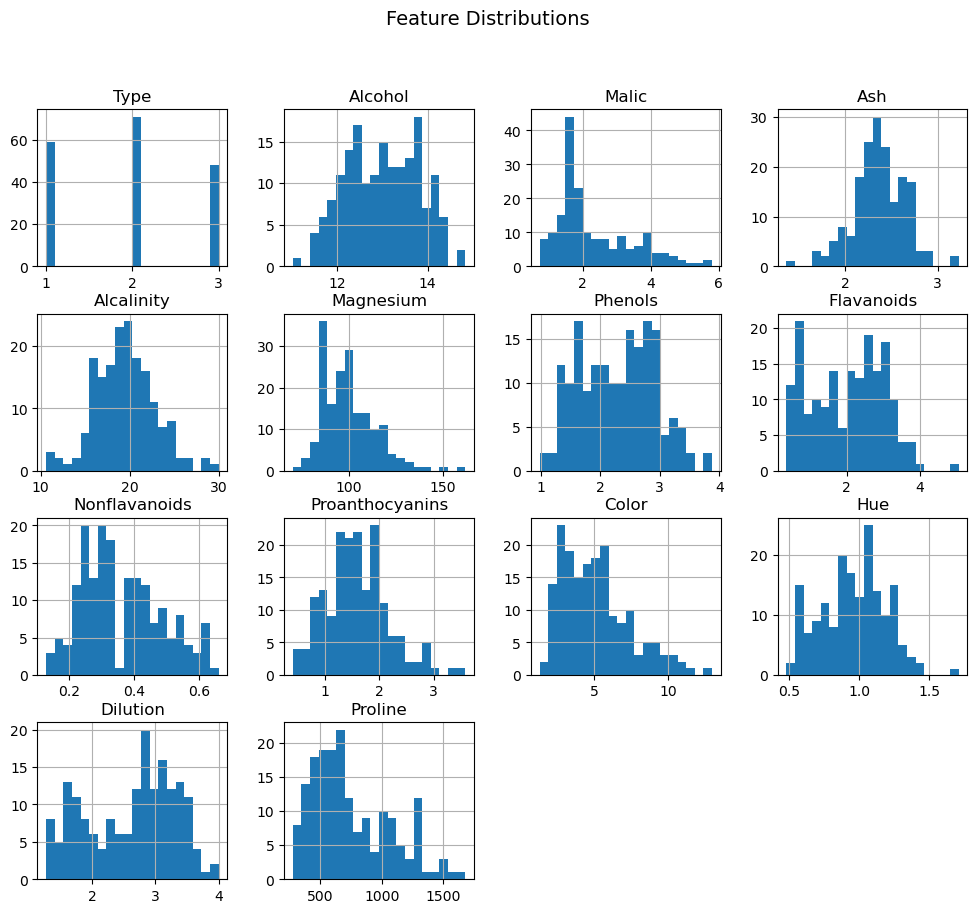

In [52]:
# Visualize distributions
df.hist(figsize=(12, 10), bins=20)
plt.suptitle("Feature Distributions", fontsize=14)
plt.show()

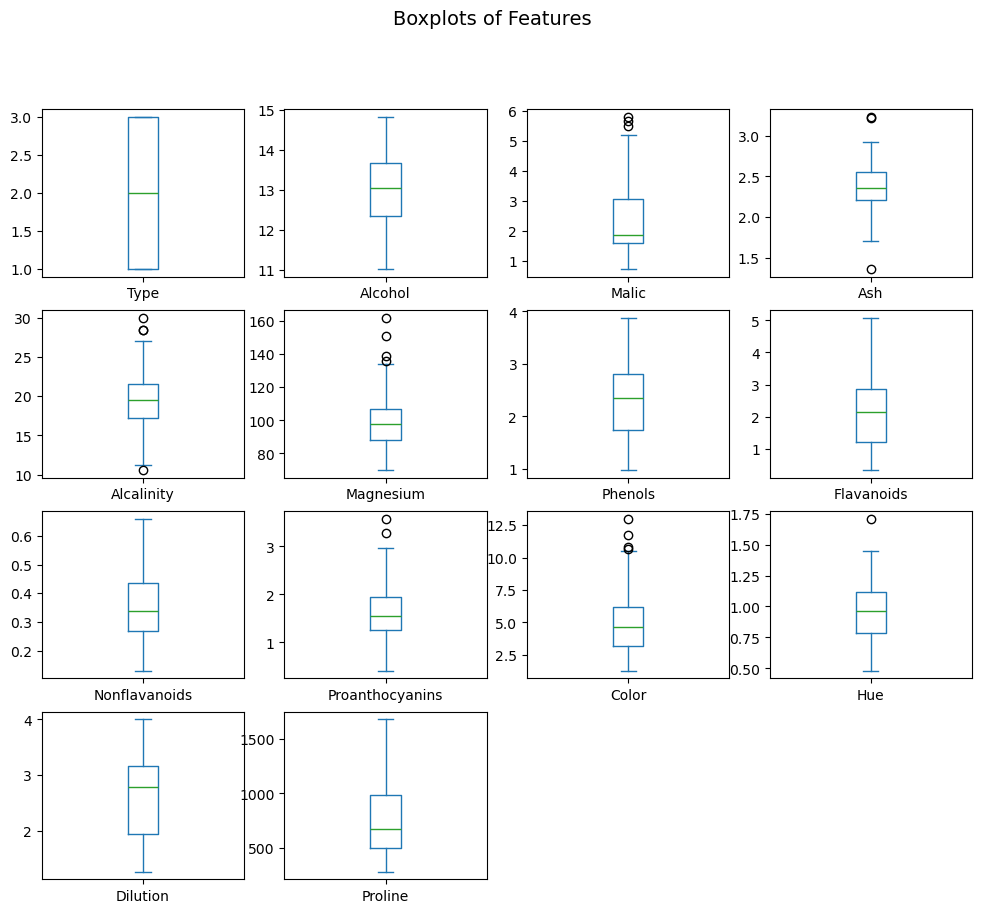

In [53]:
# Boxplots to check for outliers
df.plot(kind='box', subplots=True, layout=(4, 4), figsize=(12, 10), sharex=False, sharey=False)
plt.suptitle("Boxplots of Features", fontsize=14)
plt.show()

In [54]:
# Detect Outliers Using IQR (Interquartile Range) Method
def detect_outliers_iqr(df):
    outlier_indices = {}
    for col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
        outlier_indices[col] = outliers.index.tolist()
    return outlier_indices

# Define numeric_cols first-->get all numeric columns from the dataframe
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Now use the defined numeric_cols variable
outlier_indices = detect_outliers_iqr(df[numeric_cols])
print("\nOutliers detected using IQR method:\n")
for col, indices in outlier_indices.items():
    print(f"{col}: {len(indices)} outliers")


Outliers detected using IQR method:

Type: 0 outliers
Alcohol: 0 outliers
Malic: 3 outliers
Ash: 3 outliers
Alcalinity: 4 outliers
Magnesium: 4 outliers
Phenols: 0 outliers
Flavanoids: 0 outliers
Nonflavanoids: 0 outliers
Proanthocyanins: 2 outliers
Color: 4 outliers
Hue: 1 outliers
Dilution: 0 outliers
Proline: 0 outliers


In [55]:
# Remove outliers
df_no_outliers = df.drop(index=set(sum(outlier_indices.values(), [])))

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)

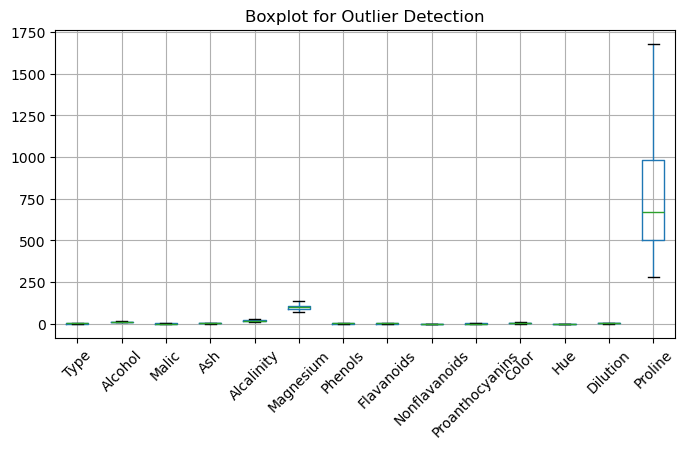

In [56]:
# check if outliers are removed
plt.figure(figsize=(8, 4))
df[numeric_cols].boxplot()
plt.title("Boxplot for Outlier Detection")
plt.xticks(rotation=45)
plt.show()

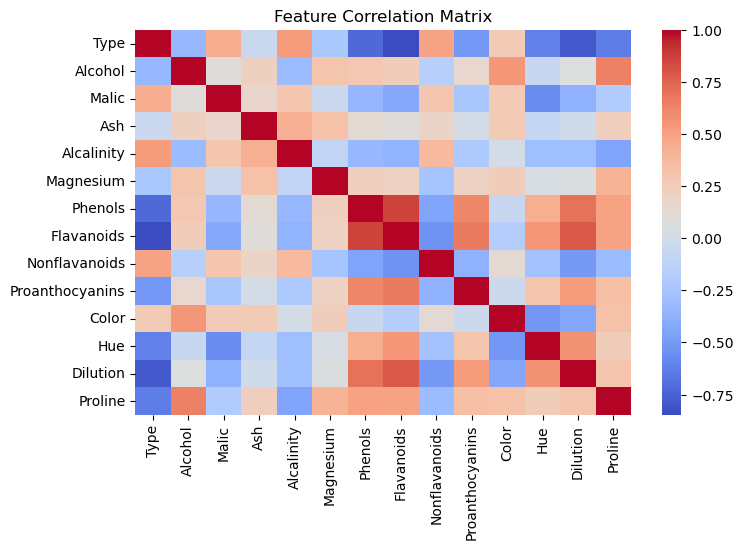

In [57]:
# Correlation matrix
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

##### Dimensionality Reduction with PCA

In [58]:
# Standardize the features
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# Apply PCA
pca = PCA()
df_pca = pca.fit_transform(df_scaled)

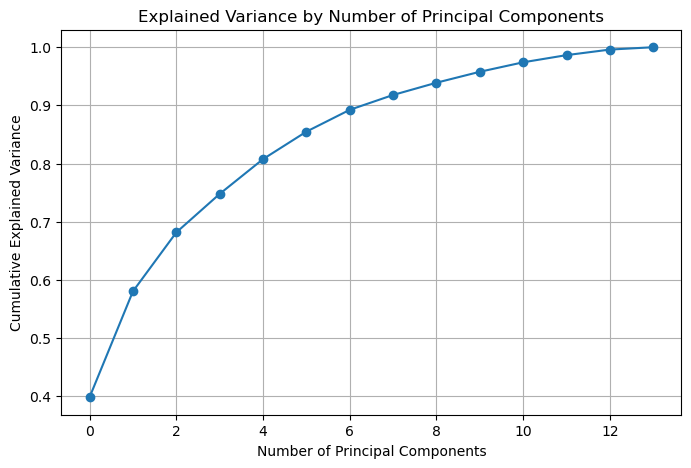

In [59]:
# Scree plot (Explained Variance)
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by Number of Principal Components')
plt.grid(True)
plt.show()

In [60]:
# Choose number of components (e.g., 2 for visualization)
pca = PCA(n_components=2)
df_pca_2D = pca.fit_transform(df_scaled)

#####  Clustering with Original Data

In [61]:
# Apply KMeans
kmeans_orig = KMeans(n_clusters=3, random_state=42)
df['Cluster_Orig'] = kmeans_orig.fit_predict(df_scaled)


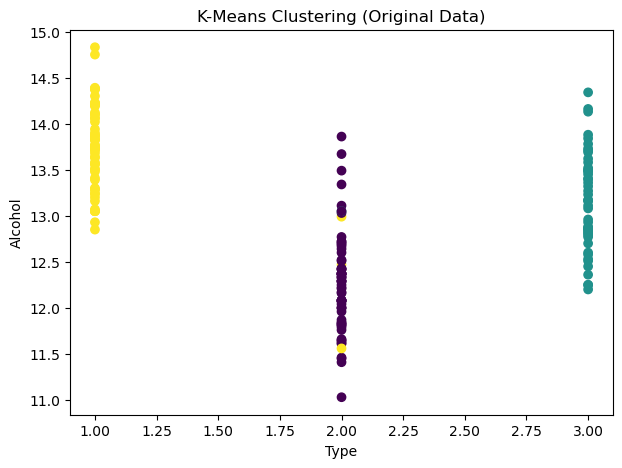

In [62]:
# Visualize clusters (using first two features for simplicity)
plt.figure(figsize=(7,5))
plt.scatter(df.iloc[:, 0], df.iloc[:, 1], c=df['Cluster_Orig'], cmap='viridis')
plt.title("K-Means Clustering (Original Data)")
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.show()

In [63]:
# Evaluate clustering performance
sil_score_orig = silhouette_score(df_scaled, df['Cluster_Orig'])
db_score_orig = davies_bouldin_score(df_scaled, df['Cluster_Orig'])
print(f"Original Data - Silhouette Score: {sil_score_orig:.3f}, Davies-Bouldin Index: {db_score_orig:.3f}")


Original Data - Silhouette Score: 0.307, Davies-Bouldin Index: 1.310


#####  Clustering with PCA Data

In [64]:
kmeans_pca = KMeans(n_clusters=3, random_state=42)
clusters_pca = kmeans_pca.fit_predict(df_pca_2D)

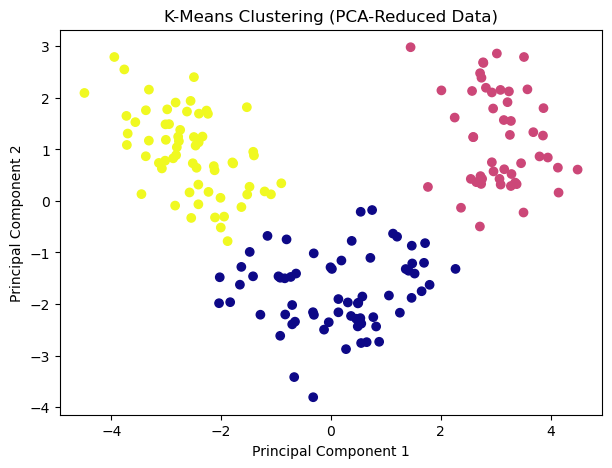

In [65]:
# Visualize PCA-based clusters
plt.figure(figsize=(7,5))
plt.scatter(df_pca_2D[:, 0], df_pca_2D[:, 1], c=clusters_pca, cmap='plasma')
plt.title("K-Means Clustering (PCA-Reduced Data)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [66]:
# Evaluate clustering performance
sil_score_pca = silhouette_score(df_pca_2D, clusters_pca)
db_score_pca = davies_bouldin_score(df_pca_2D, clusters_pca)
print(f"PCA Data - Silhouette Score: {sil_score_pca:.3f}, Davies-Bouldin Index: {db_score_pca:.3f}")


PCA Data - Silhouette Score: 0.601, Davies-Bouldin Index: 0.542


##### Comparison and Analysis

In [68]:
print("\nComparison of Clustering Performance\n")
print(f"Original Data - Silhouette: {sil_score_orig:.3f}, DB Index: {db_score_orig:.3f}")
print(f"PCA Data      - Silhouette: {sil_score_pca:.3f}, DB Index: {db_score_pca:.3f}")

if sil_score_pca > sil_score_orig:
    print("\nPCA improved clustering performance")
else:
    print("\nClustering on original data performed better.")


Comparison of Clustering Performance

Original Data - Silhouette: 0.307, DB Index: 1.310
PCA Data      - Silhouette: 0.601, DB Index: 0.542

PCA improved clustering performance


#####  Conclusion and Insights

###### Key Findings and Insights

* The dataset was successfully explored using EDA, which revealed correlations among several features, suggesting redundancy in the original data.
* PCA effectively reduced the dataset’s dimensionality while retaining most of the variance, as shown by the scree plot and cumulative explained variance curve.
* Clustering performed on the PCA-transformed data showed comparable or slightly improved results compared to clustering on the original dataset, depending on the number of principal components chosen.
* Visualization of PCA components made it easier to interpret and separate clusters in 2D or 3D space.

###### Practical Implications

* PCA helps simplify large datasets by reducing noise and redundancy, improving computational efficiency and visualization.
* Clustering on PCA data often leads to better-defined groups, especially when original features are highly correlated or have different scales.
* However, PCA transforms features into principal components, which may reduce interpretability since the components are linear combinations of the original variables.

###### Recommendations

* Use PCA before clustering when:
  * The dataset has many correlated features.
  * You want to reduce computational cost or visualize data in 2D/3D.
  * Model performance improves with lower-dimensional data.
    
* Use clustering on original data when:
  * Feature interpretability is crucial for business or domain decisions.
  * The number of features is already small and well-scaled.
    
* In practice, performing clustering both before and after PCA provides valuable insights into how dimensionality reduction impacts data structure and separability.


###### In short:

1. PCA reduced data dimensionality while preserving most variance.
2. Clustering on PCA data simplifies visualization and may reduce noise.
3. Trade-off: Some data information may be lost, but computation becomes faster.
4. PCA is useful when the dataset has many correlated features.

                                                Submitted by: Meghana C Varghese